In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import zipfile
import os
import shutil
import random
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input, decode_predictions
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
from google.colab import files
import warnings
import pydot
import graphviz
import gdown


# Suppress warnings and configure TensorFlow logging
warnings.filterwarnings('ignore', category=FutureWarning)
tf.get_logger().setLevel('ERROR')


In [2]:
# connecting my drive to google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
zip_path = "/content/drive/MyDrive/archive.zip"
extract_dir = "/content/data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

print("Extraction Complete")
print("Folders found:", os.listdir(extract_dir))

Extraction Complete
Folders found: ['1HZhs21IE2oNn_V7PF_atNDizdhV8z-vP']


In [4]:
!ls -lh /content/data

total 844M
-rw-r--r-- 1 root root 844M Oct 27 11:12 1HZhs21IE2oNn_V7PF_atNDizdhV8z-vP


In [5]:
zip_path = "/content/data/1HZhs21IE2oNn_V7PF_atNDizdhV8z-vP"  # the ZIP file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/data")

In [6]:
!ls /content/data

1HZhs21IE2oNn_V7PF_atNDizdhV8z-vP  nigfoodai


In [7]:
# splitting our data into training and validation(testing) data

base_dir = '/content/data/nigfoodai'         # where the extracted food folders are
train_dir = '/content/data_split/train'         # new training der
val_dir = '/content/data_split/validation'      # new validation folder

os.makedirs(train_dir, exist_ok=True) # basically making the folder
os.makedirs(val_dir, exist_ok=True)


for category in os.listdir(base_dir):  # os.listdir returns a string of everything in the 'base_dir'. 'category' is just a name
    category_path = os.path.join(base_dir, category) # joins the path
    if os.path.isdir(category_path):
        os.makedirs(os.path.join(train_dir, category), exist_ok=True)
        os.makedirs(os.path.join(val_dir, category), exist_ok=True)

        images = os.listdir(category_path)
        random.shuffle(images)

        train_images = images[:int(0.8 * len(images))]
        val_images = images[int(0.8 * len(images)):]

        for img in train_images:
            shutil.copy(os.path.join(category_path, img),
                os.path.join(train_dir, category, img))

        for img in val_images:
            shutil.copy(os.path.join(category_path, img),
                os.path.join(val_dir, category, img))

In [8]:
# Data Preprocessing

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    "/content/data_split/train",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

val_generator = val_datagen.flow_from_directory(
    "/content/data_split/validation",
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)


Found 2754 images belonging to 14 classes.
Found 695 images belonging to 14 classes.


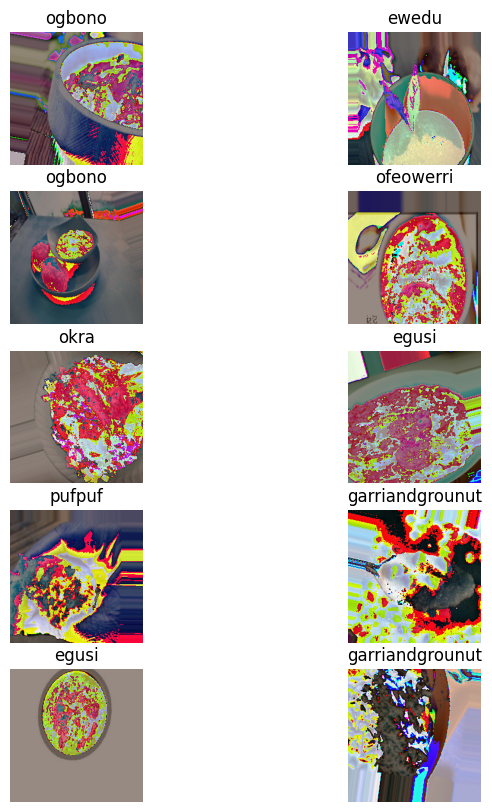

In [9]:
class_labels = list(train_generator.class_indices.keys())
images, labels = next(iter(train_generator))

plt.figure(figsize=(8, 10))
for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(images[i].astype("uint8"))
    plt.title(class_labels[np.argmax(labels[i])])
    plt.axis('off')


In [10]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(len(train_generator.class_indices), activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [11]:
# Train the model
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_generator,
        steps_per_epoch=train_generator.samples // train_generator.batch_size,
        validation_data=val_generator,
        validation_steps=val_generator.samples // val_generator.batch_size,
        epochs=5
    )

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 86s 844ms/step - accuracy: 0.4921 - loss: 1.9769 - val_accuracy: 0.7485 - val_loss: 0.7823
Epoch 2/5
 1/86 ━━━━━━━━━━━━━━━━━━━━ 8s 104ms/step - accuracy: 0.7500 - loss: 0.6584

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 75ms/step - accuracy: 0.7500 - loss: 0.6584 - val_accuracy: 0.7307 - val_loss: 0.8115
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 64s 739ms/step - accuracy: 0.7887 - loss: 0.6480 - val_accuracy: 0.7560 - val_loss: 0.8903
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 6s 73ms/step - accuracy: 0.7500 - loss: 0.7737 - val_accuracy: 0.7589 - val_loss: 0.9012
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 67s 774ms/step - accuracy: 0.8347 - loss: 0.5000 - val_accuracy: 0.7946 - val_loss: 0.6287


In [12]:
# Validate the model
loss, accuracy = model.evaluate(val_generator)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")

22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 509ms/step - accuracy: 0.7991 - loss: 0.6251
Validation Loss: 0.6178
Validation Accuracy: 79.86%


In [13]:
# Save the model
model.save("food_classification_model.h5")

# Download the model
files.download("food_classification_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving stuff.webp to stuff.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
✅ Predicted class: garriandgrounut


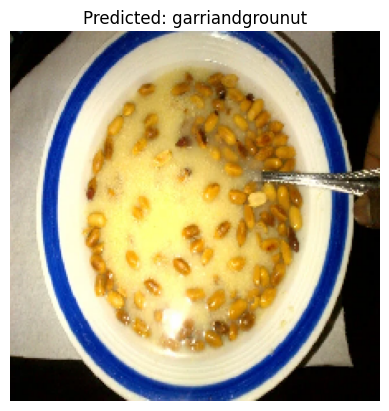

In [22]:
# Upload the images from your device
uploaded_images = files.upload()

# Get uploaded image file path
img_path = next(iter(uploaded_images))

# Load and resize the image to match model input shape
img = image.load_img(img_path, target_size=(224, 224))

# Convert to array
img_array = image.img_to_array(img)

# Expand dimensions (add batch axis)
img_array = np.expand_dims(img_array, axis=0)

# Preprocess input for ResNet50
img_array = preprocess_input(img_array)

# Predict the class of the uploaded image
predictions = model.predict(img_array)

# Get the predicted class name
predicted_class = list(train_generator.class_indices.keys())[np.argmax(predictions)]

print(f"✅ Predicted class: {predicted_class}")

# Display the image with prediction
plt.imshow(img)
plt.title(f'Predicted: {predicted_class}')
plt.axis('off')
plt.show()
